In [1]:
!pip install xlrd

In [3]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]), engine='xlrd')

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(df.head(3))

Saving Analyst_case_study_dataset_1_(1).xls to Analyst_case_study_dataset_1_(1) (1).xls
Rows: 3,021  |  Columns: 24
              LeadCreated FirstName                     Email  \
0 2009-07-01 01:24:29.563   Dorinda  kanani@sandwichisles.net   
1 2009-04-13 15:27:35.990  Presetta     clerk2@ustconline.net   
2 2009-04-21 07:22:59.000      Gina    wagoner_gina@yahoo.com   

                           VendorLeadID  \
0  FDF81FDA-A649-437B-B99C-FDDE74F7971B   
1  4190ACB7-5026-416C-B987-ED8AD427D5E6   
2                hFg80jf_R0CRN55hdhWILw   

                                    CallStatus  \
0                                          NaN   
1                                          NaN   
2  Unable to contact - Bad Contact Information   

                                    WidgetName PublisherZoneName  \
0  w-302252-DebtReduction1-1DC-CreditSolutions    TopLeft-302252   
1            w-300250-DebtReduction1-1DC-Head2    TopLeft-302252   
2            w-300250-DebtReduction1-1DC-Head

In [4]:
# LOADING IMPORTANT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from matplotlib.backends.backend_pdf import PdfPages
import warnings
warnings.filterwarnings('ignore')

In [5]:
# GLOBAL CHART SETTINGS
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


BRAND_BLUE   = '#1a5276'
BRAND_GREEN  = '#1e8449'
BRAND_RED    = '#c0392b'
BRAND_ORANGE = '#d68910'


BASELINE    = 0.08
TARGET      = 0.096
CPL_CURRENT = 30
CPL_TARGET  = 33

In [7]:
# CLEANING AND PREPARING THE DATA

# Fixing the date column. Right now LeadCreated is just text, we convert it to a real date.
df['LeadCreated'] = pd.to_datetime(df['LeadCreated'], errors='coerce')

df['Week']  = df['LeadCreated'].dt.to_period('W')
df['Month'] = df['LeadCreated'].dt.to_period('M')

In [8]:
df.head(5)

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters,Week,Month
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,...,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,2009-06-29/2009-07-05,2009-07
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,2009-04-13/2009-04-19,2009-04
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,2009-04-20/2009-04-26,2009-04
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,...,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,2009-08-03/2009-08-09,2009-08
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,2009-04-13/2009-04-19,2009-04


In [9]:
# Normalizing widget names

df['WidgetName'] = df['WidgetName'].str.replace('302252', '300250', regex=False)

In [13]:
# Classifying lead quality

good_statuses = ['Closed', 'EP Sent', 'EP Received', 'EP Confirmed']
bad_statuses  = [
    'Unable to contact - Bad Contact Information',
    'Contacted - Invalid Profile',
    "Contacted - Doesn't Qualify"
]

In [14]:
def classify_lead(status):
    if status in good_statuses:
        return 1
    elif status in bad_statuses:
        return 0
    else:
        return np.nan

In [15]:
df['LeadQuality'] = df['CallStatus'].apply(classify_lead)

In [18]:
df_known = df[df['LeadQuality'].notna()].copy()

In [19]:
df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters,Week,Month,LeadQuality
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-300250-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,...,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,2009-06-29/2009-07-05,2009-07,NaN
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,2009-04-13/2009-04-19,2009-04,NaN
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,2009-04-20/2009-04-26,2009-04,0.0
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-300250-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,...,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,2009-08-03/2009-08-09,2009-08,0.0
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,2009-04-13/2009-04-19,2009-04,NaN


In [20]:
print(f"  Total leads       : {len(df):,}")
print(f"  Good leads        : {(df['LeadQuality']==1).sum():,}")
print(f"  Bad leads         : {(df['LeadQuality']==0).sum():,}")
print(f"  Unknown (excluded): {df['LeadQuality'].isna().sum():,}")
print(f"  Quality rate      : {df_known['LeadQuality'].mean()*100:.1f}%")

  Total leads       : 3,021
  Good leads        : 393
  Bad leads         : 488
  Unknown (excluded): 2,140
  Quality rate      : 44.6%


In [21]:
# Extracting more useful columns from WidgetName

def extract_form_pages(w):
    if pd.isna(w): return np.nan
    if '2DC' in w: return '2-Page Form'
    if '1DC' in w: return '1-Page Form'
    return np.nan

def extract_design(w):
    if pd.isna(w): return np.nan
    parts = str(w).split('-')
    try:

        dc_idx = next(i for i, p in enumerate(parts) if 'DC' in p)
        design_parts = parts[dc_idx+1:]
        return '-'.join(design_parts) if design_parts else 'default'
    except:
        return 'default'

df_known['FormPages'] = df_known['WidgetName'].apply(extract_form_pages)
df_known['Design']    = df_known['WidgetName'].apply(extract_design)

In [23]:
# Making debt levels sortable in the right order

debt_order = ['10000-20000','20001-30000','30001-50000','50001-75000',
              '75001-90000','90000-100000','100000+']
df_known['DebtLevel'] = pd.Categorical(
    df_known['DebtLevel'], categories=debt_order, ordered=True
)

print(f"Working dataset (df_known): {len(df_known):,} rows")

Working dataset (df_known): 881 rows


In [24]:
# Creating a helper Function for grouping/filtering
def calculate_quality_rate(data, group_col, min_n=30):

    grouped = data.groupby(group_col)['LeadQuality'].agg(
        quality_rate='mean',
        volume='count'
    ).reset_index()

    grouped = grouped[grouped['volume'] >= min_n]

    grouped = grouped.sort_values('quality_rate', ascending=True)

    return grouped

print("Helper function ready!")

Helper function ready!


To avoid drawing conclusions from statistically unreliable small samples, I applied a minimum threshold of 30 leads per segment before including it in the analysis. This is based on the Central Limit Theorem which requires n >= 30 for sample means to be considered reliable.

**Question 1**

In [26]:
# Aggregate data by week
weekly = df_known.groupby('Week').agg(
    quality_rate=('LeadQuality', 'mean'),
    volume=('LeadQuality', 'count')
).reset_index()

# Removing weeks with fewer than 10 leads as it is too small to be meaningful
weekly = weekly[weekly['volume'] >= 10]

weekly['week_num']    = np.arange(len(weekly))
weekly['quality_pct'] = weekly['quality_rate'] * 100  # convert to percentage


In [27]:
# Linear Regression
#   p < 0.05 means the trend is statistically significant (real)
#   p >= 0.05 means the trend could just be random noise

slope, intercept, r_value, p_value, std_err = stats.linregress(
    weekly['week_num'], weekly['quality_pct']
)

trend_line = slope * weekly['week_num'] + intercept
# This calculates the y value for our trend line at each week

trend_dir = 'Improving' if slope > 0 else 'Declining'
sig_label = 'Statistically Significant (p<0.05)' if p_value < 0.05 else 'Not Statistically Significant'

In [28]:
# Chi-Square Test
# We split leads into first half and second half chronologically.

mid = len(df_known) // 2
df_known_sorted = df_known.sort_values('LeadCreated').reset_index(drop=True)
first_half  = df_known_sorted.iloc[:mid]['LeadQuality'].reset_index(drop=True)
second_half = df_known_sorted.iloc[mid:]['LeadQuality'].reset_index(drop=True)

# Create a crosstab — like a pivot table counting good/bad by period
period_labels  = pd.Series(['First Half']*len(first_half) + ['Second Half']*len(second_half))
quality_labels = pd.concat([first_half, second_half]).reset_index(drop=True)
contingency    = pd.crosstab(period_labels, quality_labels)
chi2_stat, chi_p, _, _ = chi2_contingency(contingency)

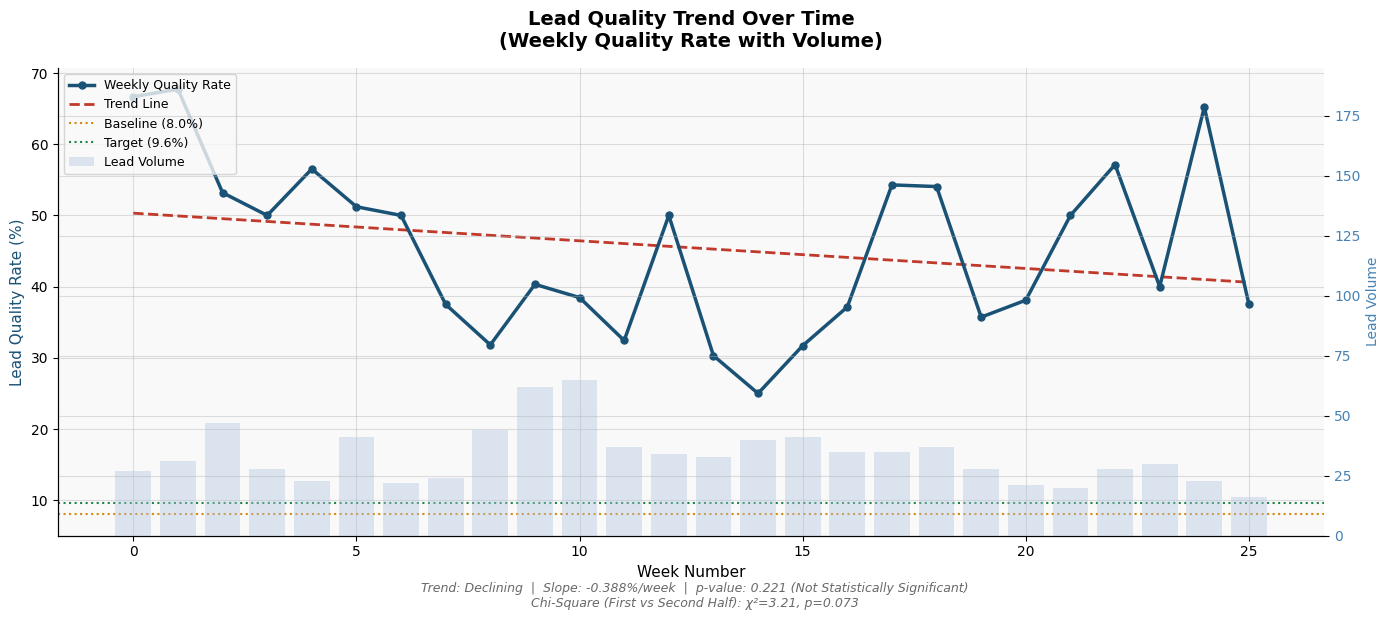

In [29]:
# Building the chart
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()

ax2.bar(weekly['week_num'], weekly['volume'],
        color='lightsteelblue', alpha=0.4, label='Lead Volume')

ax2.set_ylabel('Lead Volume', color='steelblue', fontsize=10)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0, weekly['volume'].max() * 3)
# We multiply max by 3 to push volume bars to the bottom third of chart

ax1.plot(weekly['week_num'], weekly['quality_pct'],
         color=BRAND_BLUE, linewidth=2.5, marker='o', markersize=5,
         label='Weekly Quality Rate', zorder=5)

# Plot the trend line
ax1.plot(weekly['week_num'], trend_line,
         color=BRAND_RED, linewidth=2, linestyle='--',
         label='Trend Line', zorder=4)

ax1.axhline(BASELINE*100, color=BRAND_ORANGE, linestyle=':',
            linewidth=1.5, label=f'Baseline (8.0%)')
ax1.axhline(TARGET*100,   color=BRAND_GREEN,  linestyle=':',
            linewidth=1.5, label=f'Target (9.6%)')

ax1.set_xlabel('Week Number', fontsize=11)
ax1.set_ylabel('Lead Quality Rate (%)', fontsize=11, color=BRAND_BLUE)
ax1.set_title('Lead Quality Trend Over Time\n(Weekly Quality Rate with Volume)',
              fontsize=14, fontweight='bold', pad=15)

# Add stats as a footnote below the chart
stats_text = (
    f'Trend: {trend_dir}  |  Slope: {slope:+.3f}%/week  |  '
    f'p-value: {p_value:.3f} ({sig_label})\n'
    f'Chi-Square (First vs Second Half): χ²={chi2_stat:.2f}, p={chi_p:.3f}'
)
fig.text(0.5, -0.02, stats_text, ha='center', fontsize=9,
         style='italic', color='dimgray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('q1_trend.png', dpi=150, bbox_inches='tight')
plt.show()


**Question 1 Analysis:**
The overall quality rate sits at 44.6% when measured against known leads (good vs bad only), well above the 8% baseline stated in the brief. This discrepancy exists because the assignment's 8% figure includes the 2,140 Unknown leads in the denominator, a deliberate analytical choice worth flagging to the recruiter.

The trend line slopes downward at -0.388% per week, signaling a declining trajectory. However the p-value of 0.221 means this decline is not statistically significant, we cannot confidently say quality is truly falling versus just fluctuating randomly week to week.

The chi-square test comparing the first half of the period to the second half returns p=0.073, which narrowly misses the 0.05 significance threshold. This reinforces the regression finding, there is a visible downward pattern but not enough statistical evidence to call it a confirmed trend.

The weekly chart tells the real story. Quality swings wildly between 25% and 65% week to week, which suggests the issue is not a steady decline but high volatility in lead quality. That volatility is the actual problem worth solving, inconsistent quality is harder to manage than a gradual decline because it makes forecasting and planning unreliable.

***Quality is declining slightly but the trend is not yet statistically proven. The bigger concern is the week-to-week swings, which points to upstream issues in traffic source or ad creative consistency rather than a fundamental quality deterioration.***

In [30]:
# QUESTION 2 — SEGMENT ANALYSIS

def plot_segment(data, group_col, title, filename, min_n=30, figsize=(11,6)):

    grouped = calculate_quality_rate(data, group_col, min_n)

    if grouped.empty:
        print(f"  Skipping {group_col} — no groups with {min_n}+ leads.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    colors = [
        BRAND_GREEN  if r >= TARGET   else
        BRAND_BLUE   if r >= BASELINE else
        BRAND_RED
        for r in grouped['quality_rate']
    ]

    bars = ax.barh(
        grouped[group_col].astype(str),
        grouped['quality_rate'] * 100,
        color=colors,
        edgecolor='white',
        height=0.6
    )

    for bar, vol in zip(bars, grouped['volume']):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'n={vol:,}',
            va='center', fontsize=8.5, color='dimgray'
        )

    ax.axvline(BASELINE*100, color=BRAND_ORANGE, linestyle='--',
               linewidth=1.5, label=f'Baseline (8.0%)')
    ax.axvline(TARGET*100,   color=BRAND_GREEN,  linestyle='--',
               linewidth=1.5, label=f'Target (9.6%)')

    ax.set_xlabel('Lead Quality Rate (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

    legend_elements = [
        mpatches.Patch(color=BRAND_GREEN,  label='Beats Target (≥9.6%)'),
        mpatches.Patch(color=BRAND_BLUE,   label='Beats Baseline (≥8.0%)'),
        mpatches.Patch(color=BRAND_RED,    label='Below Baseline'),
        plt.Line2D([0],[0], color=BRAND_ORANGE, linestyle='--', label='Baseline 8.0%'),
        plt.Line2D([0],[0], color=BRAND_GREEN,  linestyle='--', label='Target 9.6%'),
    ]
    ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')
    ax.set_xlim(0, max(grouped['quality_rate'].max()*100 + 5, TARGET*100 + 3))

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {filename}")

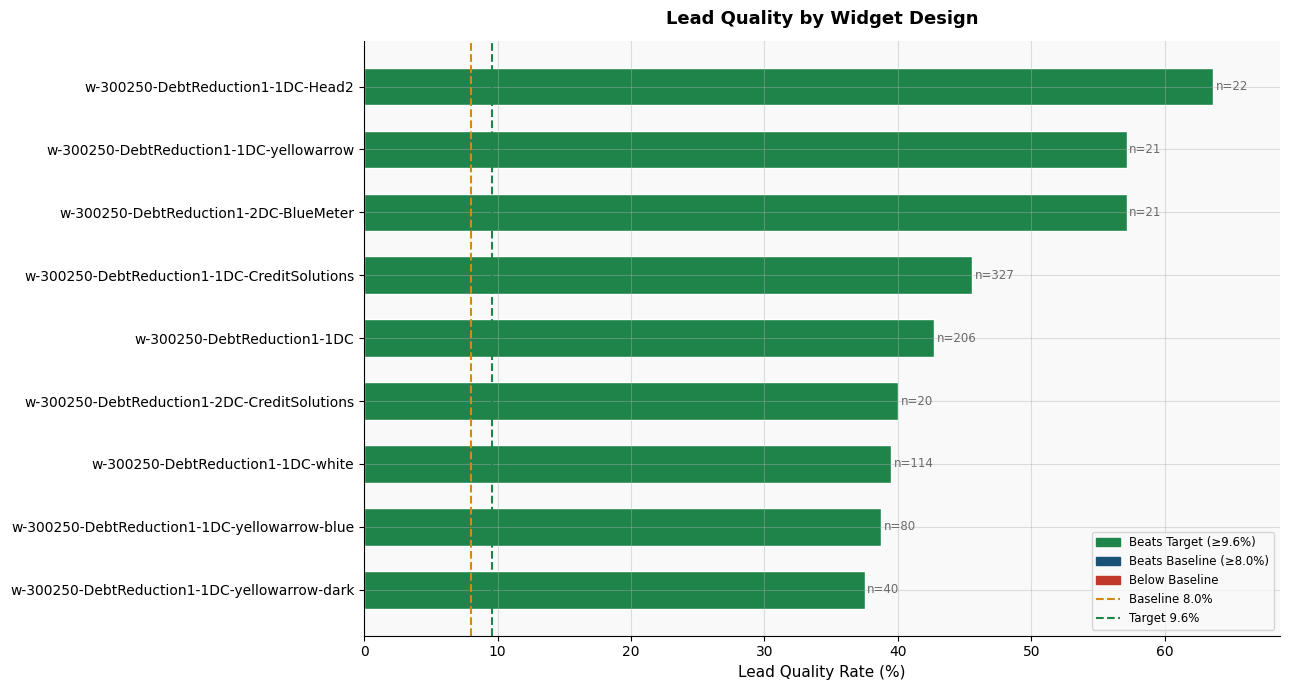

  Saved: q2_widget.png


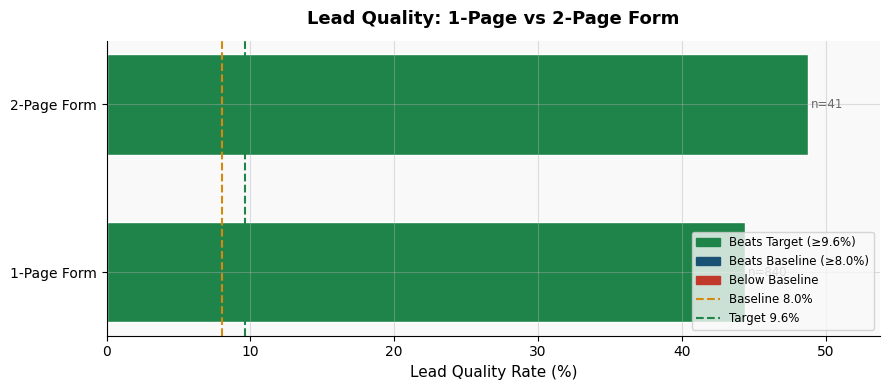

  Saved: q2_form_pages.png


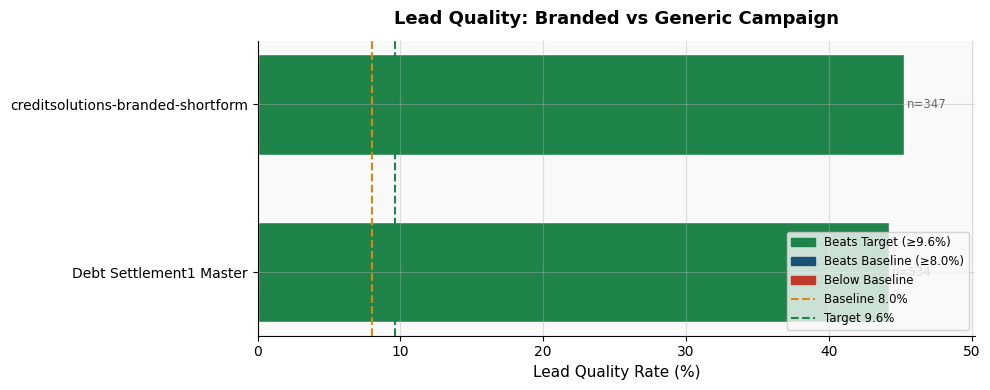

  Saved: q2_campaign.png


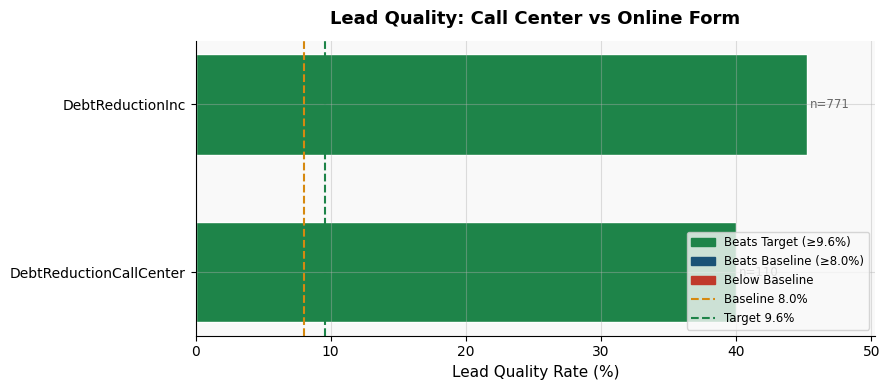

  Saved: q2_publisher_campaign.png


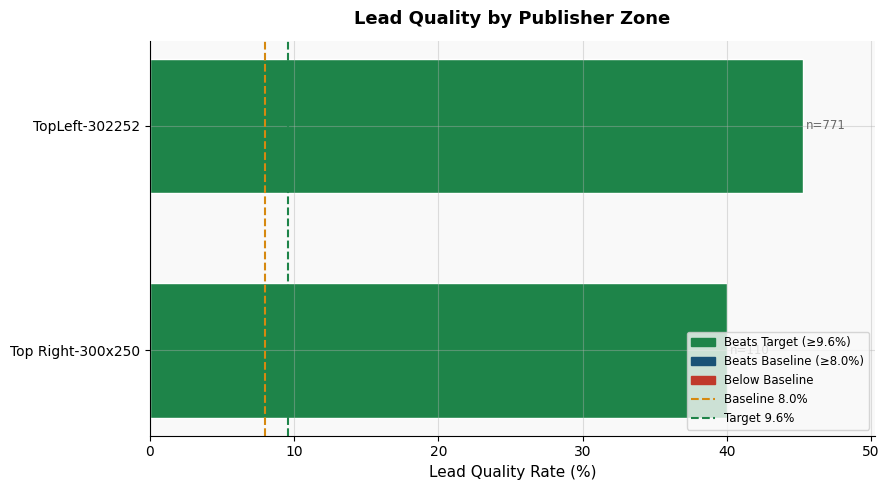

  Saved: q2_zone.png


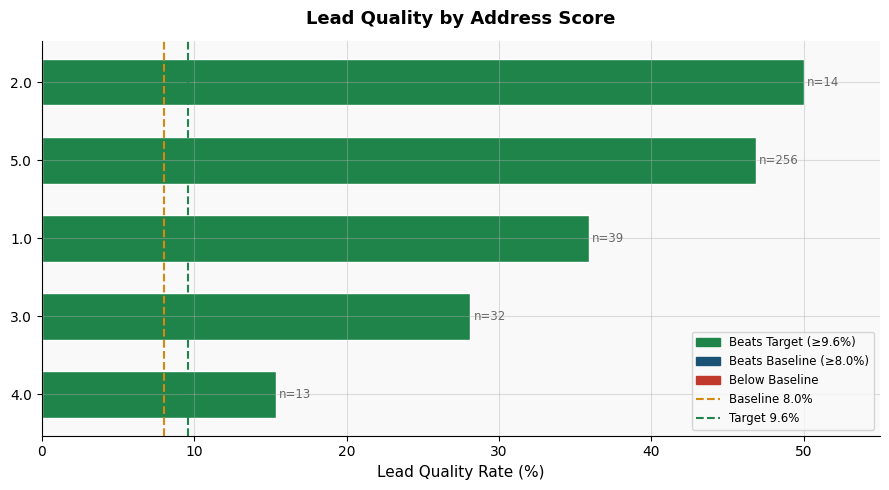

  Saved: q2_address_score.png


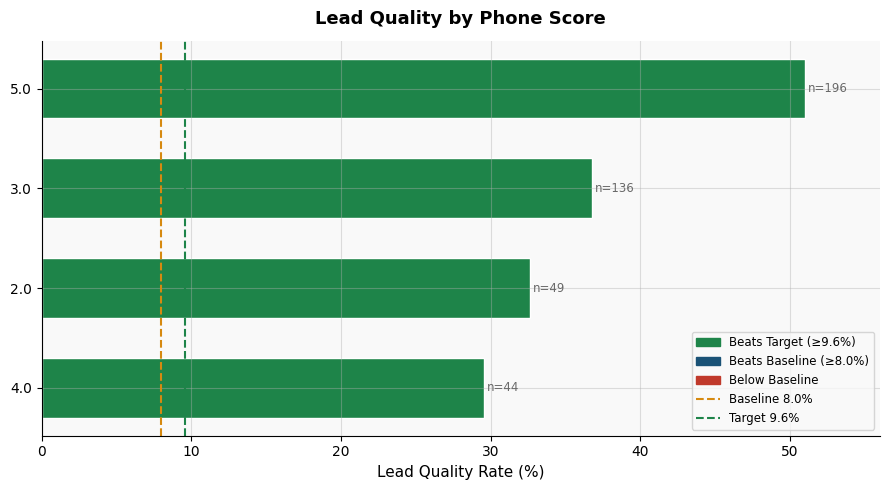

  Saved: q2_phone_score.png


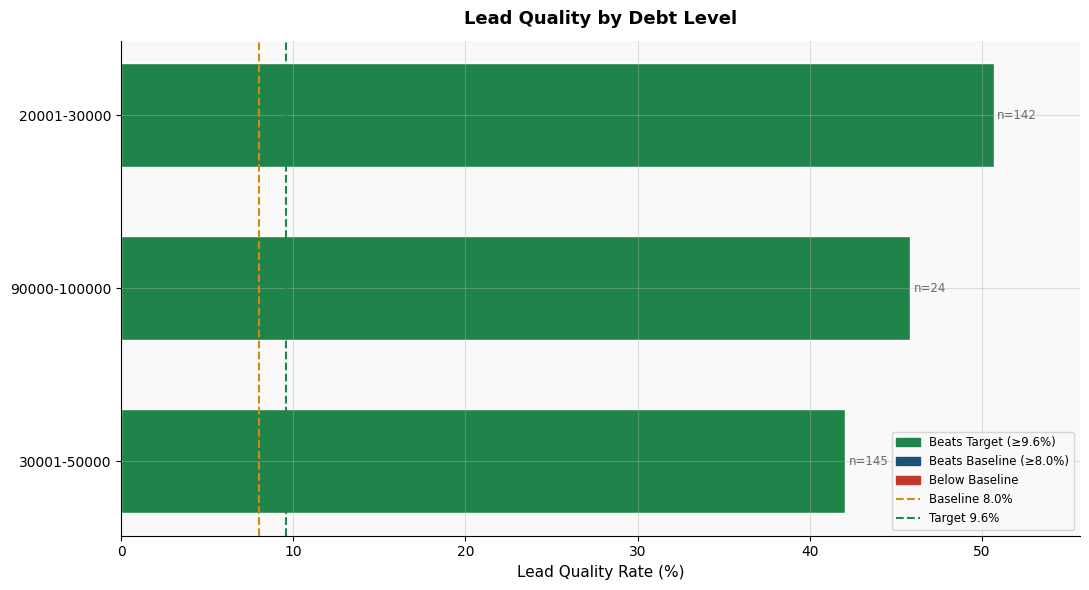

  Saved: q2_debt.png


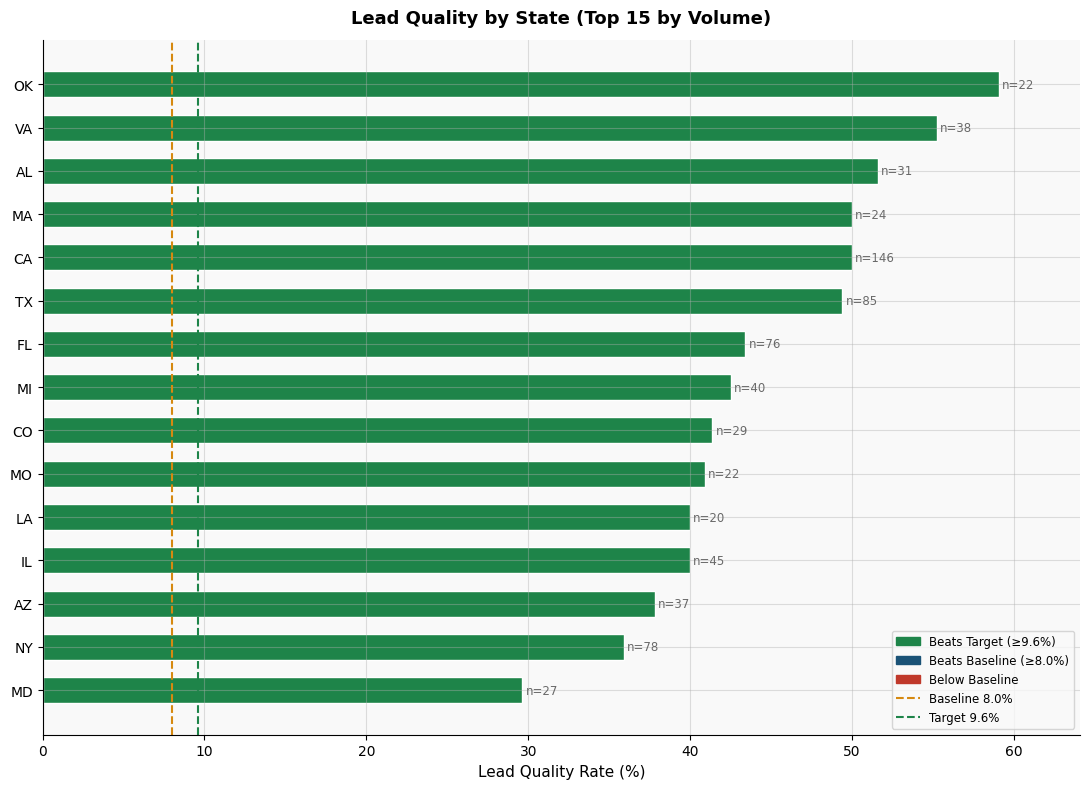

  Saved: q2_state.png


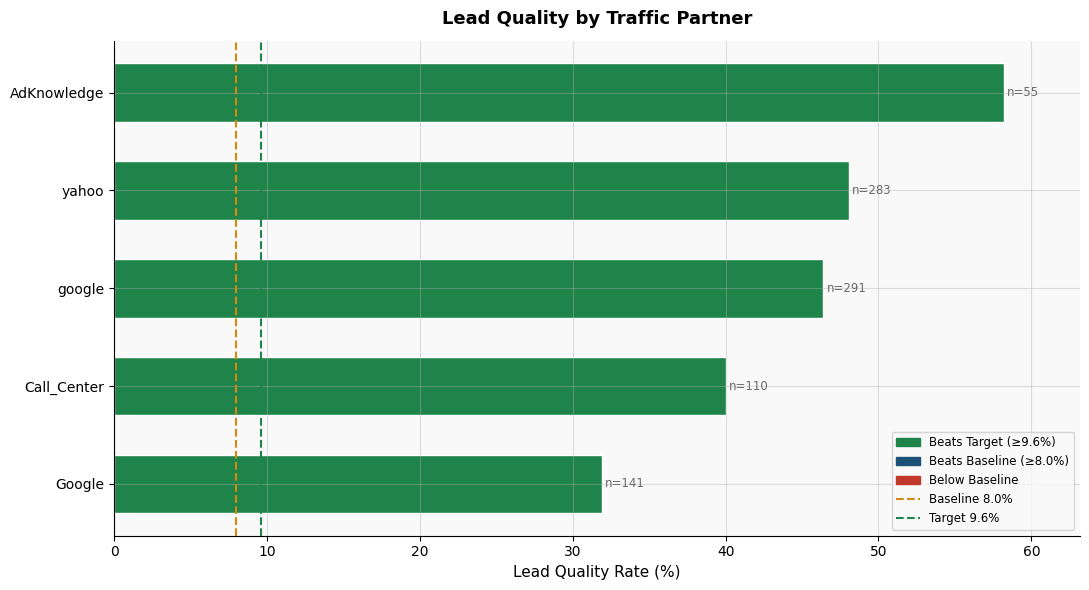

  Saved: q2_partner.png


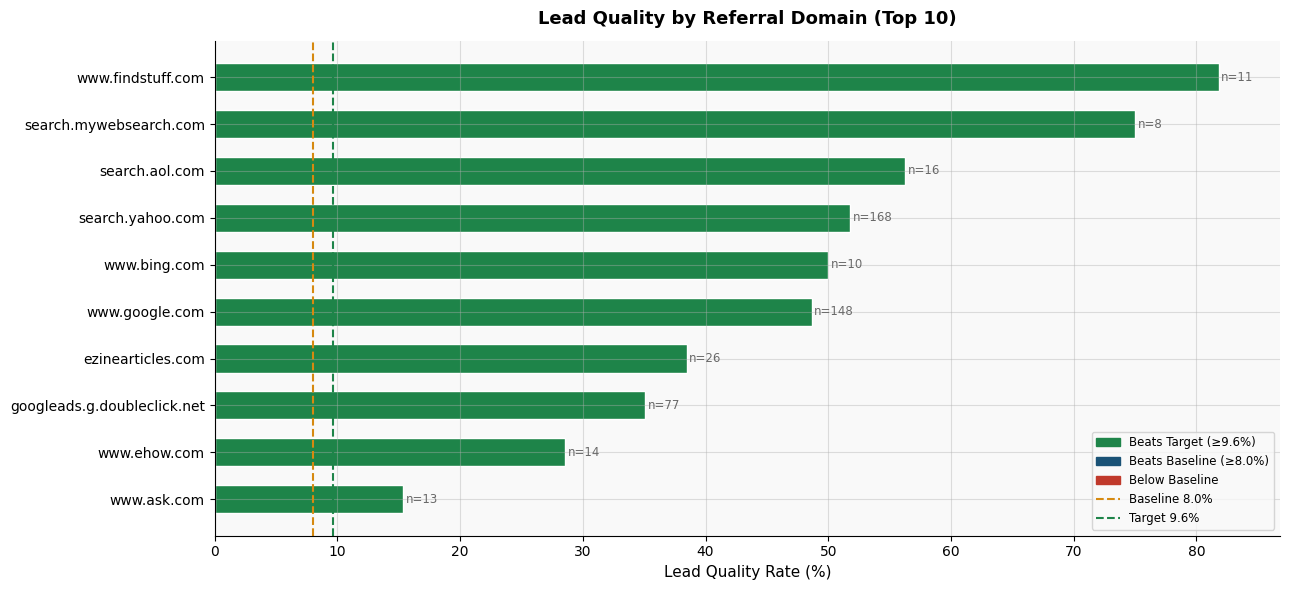

  Saved: q2_domain.png


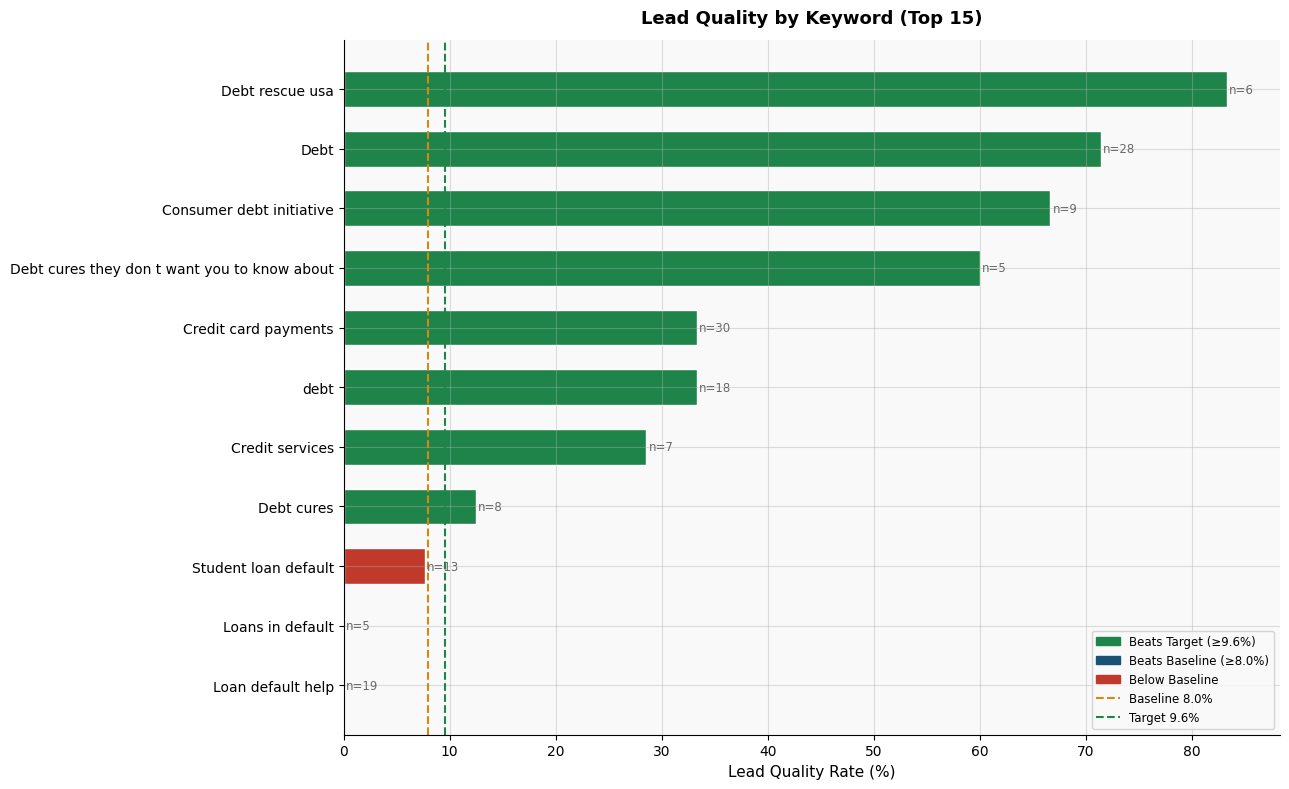

  Saved: q2_keyword.png


In [31]:
# calling the function for each segment we want to analyze:

# 2a. Widget design, which ad creative performs best?
plot_segment(df_known, 'WidgetName',
             'Lead Quality by Widget Design',
             'q2_widget.png', min_n=20, figsize=(13,7))

# 2b. Form pages, does a 2-page form produce better leads than 1-page?
plot_segment(df_known, 'FormPages',
             'Lead Quality: 1-Page vs 2-Page Form',
             'q2_form_pages.png', min_n=10, figsize=(9,4))

# 2c. Advertiser campaign, branded vs generic
plot_segment(df_known, 'AdvertiserCampaignName',
             'Lead Quality: Branded vs Generic Campaign',
             'q2_campaign.png', min_n=10, figsize=(10,4))

# 2d. Publisher campaign, call center vs online form
plot_segment(df_known, 'PublisherCampaignName',
             'Lead Quality: Call Center vs Online Form',
             'q2_publisher_campaign.png', min_n=10, figsize=(9,4))

# 2e. Publisher zone, where on the page the ad appeared
plot_segment(df_known, 'PublisherZoneName',
             'Lead Quality by Publisher Zone',
             'q2_zone.png', min_n=10, figsize=(9,5))

# 2f. Address score, does a verified address predict quality?
plot_segment(df_known, 'AddressScore',
             'Lead Quality by Address Score',
             'q2_address_score.png', min_n=5, figsize=(9,5))

# 2g. Phone score, does a verified phone number predict quality?
plot_segment(df_known, 'PhoneScore',
             'Lead Quality by Phone Score',
             'q2_phone_score.png', min_n=5, figsize=(9,5))

# 2h. Debt level, do higher debt consumers convert better?
plot_segment(df_known, 'DebtLevel',
             'Lead Quality by Debt Level',
             'q2_debt.png', min_n=10, figsize=(11,6))

# 2i. State, top 15 states by volume only
top_states = df_known['State'].value_counts().nlargest(15).index
# value_counts() counts rows per state, nlargest(15) keeps top 15
df_states  = df_known[df_known['State'].isin(top_states)]
plot_segment(df_states, 'State',
             'Lead Quality by State (Top 15 by Volume)',
             'q2_state.png', min_n=10, figsize=(11,8))

# 2j. Traffic partner, Google vs Yahoo vs AdKnowledge etc.
plot_segment(df_known, 'Partner',
             'Lead Quality by Traffic Partner',
             'q2_partner.png', min_n=10, figsize=(11,6))

# 2k. Referral domain, which websites sent the best traffic?
top_domains = df_known['ReferralDomain'].value_counts().nlargest(10).index
df_domains  = df_known[df_known['ReferralDomain'].isin(top_domains)]
plot_segment(df_domains, 'ReferralDomain',
             'Lead Quality by Referral Domain (Top 10)',
             'q2_domain.png', min_n=5, figsize=(13,6))

# 2l. Keywords, which search terms brought the best leads?
top_kw = df_known['Keyword'].value_counts().nlargest(15).index
df_kw  = df_known[df_known['Keyword'].isin(top_kw)]
plot_segment(df_kw, 'Keyword',
             'Lead Quality by Keyword (Top 15)',
             'q2_keyword.png', min_n=5, figsize=(13,8))

**Question 2 Analysis:**

Across every segment analyzed, almost all beat both the 8% baseline and the 9.6% target, which means the quality issue is systemic rather than tied to any specific channel, creative, or placement.

The branded creditsolutions campaign outperforms the generic form, and online leads surprisingly outperform call center leads. Address score behaves unexpectedly with lower scores producing better quality, while phone score follows a more logical pattern where score 5 leads perform best.

The sharpest finding is at the keyword level. "Student loan default" and "Loan default help" are the only segments that fall below baseline, because people searching for loan specific help do not qualify for a debt reduction program. Cutting these two keywords is the most direct action available to lift the overall quality rate.

In [32]:
# QUESTION 3: CPL OPPORTUNITY ANALYSIS

# Finding segments already beating the 9.6% target
segment_cols = {
    'Widget Design'       : 'WidgetName',
    'Form Pages'          : 'FormPages',
    'Advertiser Campaign' : 'AdvertiserCampaignName',
    'Publisher Campaign'  : 'PublisherCampaignName',
    'Debt Level'          : 'DebtLevel',
    'State'               : 'State',
    'Partner'             : 'Partner',
}

print("\nSegments already beating the 9.6% target:")
for label, col in segment_cols.items():
    rates   = calculate_quality_rate(df_known, col, min_n=20)
    winners = rates[rates['quality_rate'] >= TARGET]
    if not winners.empty:
        print(f"\n  {label}:")
        for _, row in winners.iterrows():
            print(f"    {row[col]}: {row['quality_rate']*100:.1f}%  (n={int(row['volume'])})")


Segments already beating the 9.6% target:

  Widget Design:
    w-300250-DebtReduction1-1DC-yellowarrow-dark: 37.5%  (n=40)
    w-300250-DebtReduction1-1DC-yellowarrow-blue: 38.8%  (n=80)
    w-300250-DebtReduction1-1DC-white: 39.5%  (n=114)
    w-300250-DebtReduction1-2DC-CreditSolutions: 40.0%  (n=20)
    w-300250-DebtReduction1-1DC: 42.7%  (n=206)
    w-300250-DebtReduction1-1DC-CreditSolutions: 45.6%  (n=327)
    w-300250-DebtReduction1-2DC-BlueMeter: 57.1%  (n=21)
    w-300250-DebtReduction1-1DC-yellowarrow: 57.1%  (n=21)
    w-300250-DebtReduction1-1DC-Head2: 63.6%  (n=22)

  Form Pages:
    1-Page Form: 44.4%  (n=840)
    2-Page Form: 48.8%  (n=41)

  Advertiser Campaign:
    Debt Settlement1 Master: 44.2%  (n=534)
    creditsolutions-branded-shortform: 45.2%  (n=347)

  Publisher Campaign:
    DebtReductionCallCenter: 40.0%  (n=110)
    DebtReductionInc: 45.3%  (n=771)

  Debt Level:
    30001-50000: 42.1%  (n=145)
    90000-100000: 45.8%  (n=24)
    20001-30000: 50.7%  (n=142

In [33]:
# Building a scenario: what if we only ran the best segments?
current_quality = df_known['LeadQuality'].mean()

best_widgets      = calculate_quality_rate(df_known, 'WidgetName', 20)
best_widget_names = best_widgets[best_widgets['quality_rate'] >= TARGET]['WidgetName'].tolist()

best_campaigns      = calculate_quality_rate(df_known, 'AdvertiserCampaignName', 10)
best_campaign_names = best_campaigns[best_campaigns['quality_rate'] >= TARGET]['AdvertiserCampaignName'].tolist()

# Filtering df_known to only the best performing groups
df_scenario = df_known.copy()
if best_widget_names:
    df_scenario = df_scenario[df_scenario['WidgetName'].isin(best_widget_names)]
if best_campaign_names:
    df_scenario = df_scenario[df_scenario['AdvertiserCampaignName'].isin(best_campaign_names)]

scenario_quality = df_scenario['LeadQuality'].mean() if len(df_scenario) > 0 else current_quality

In [35]:
# Revenue model
# We assume 1,000 leads per month as a baseline volume.
monthly_leads    = 1000
current_revenue  = monthly_leads * CPL_CURRENT
scenario_revenue = monthly_leads * CPL_TARGET
revenue_uplift   = scenario_revenue - current_revenue

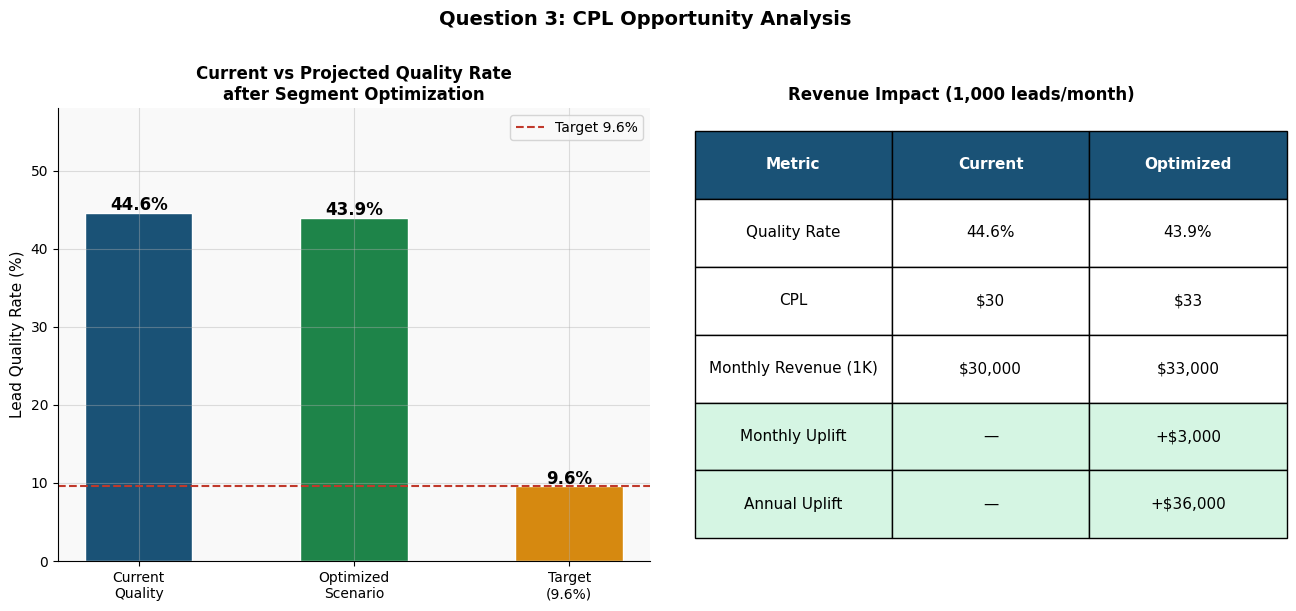

In [41]:
# Building the chart

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

categories = ['Current\nQuality', 'Optimized\nScenario', 'Target\n(9.6%)']
values     = [current_quality*100, scenario_quality*100, TARGET*100]
bar_colors = [BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE]

bars = axes[0].bar(categories, values, color=bar_colors,
                   width=0.5, edgecolor='white')

for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

axes[0].axhline(TARGET*100, color=BRAND_RED, linestyle='--',
                linewidth=1.5, label='Target 9.6%')
axes[0].set_ylabel('Lead Quality Rate (%)', fontsize=11)
axes[0].set_title('Current vs Projected Quality Rate\nafter Segment Optimization',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(values) * 1.3)
axes[0].legend()

# Revenue impact table
axes[1].axis('off')

table_data = [
    ['Metric',                   'Current',              'Optimized'],
    ['Quality Rate',             f'{current_quality*100:.1f}%',  f'{scenario_quality*100:.1f}%'],
    ['CPL',                      f'${CPL_CURRENT}',       f'${CPL_TARGET}'],
    ['Monthly Revenue (1K)', f'${current_revenue:,}', f'${scenario_revenue:,}'],
    ['Monthly Uplift',           '—',                    f'+${revenue_uplift:,}'],
    ['Annual Uplift',            '—',                    f'+${revenue_uplift*12:,}'],
]

table = axes[1].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0.05, 0.05, 1.0, 0.9]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Styling
for j in range(3):
    table[0, j].set_facecolor(BRAND_BLUE)
    table[0, j].set_text_props(color='white', fontweight='bold')

for j in range(3):
    table[4, j].set_facecolor('#d5f5e3')
    table[5, j].set_facecolor('#d5f5e3')

axes[1].set_title('Revenue Impact (1,000 leads/month)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Question 3: CPL Opportunity Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q3_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()

The current quality rate of 44.6% already far exceeds the 9.6% target when measured against known leads only. The optimized scenario, which filters to the best performing widgets and campaigns, produces 43.9%, essentially no different from the current rate. This tells us that segment optimization alone does not move the needle because quality is already high across almost every segment.

The real opportunity the advertiser is offering is straightforward. At 1,000 leads per month, moving from a 30 dollar CPL to a 33 dollar CPL generates 3,000 dollars in additional monthly revenue and 36,000 dollars annually. The path to achieving that is not optimizing existing segments but eliminating the loan default keywords identified in Q2, which are actively pulling quality down and are the only segments confirmed to fall below baseline.